# Definitive Paper Plotter

This notebook loads results directly from `artifacts/` and contains only the requested paper plots:

- Plot 2B
- Plot 2C integrated into one two-panel figure
- Plot 2E
- Plot 3B, including VideoMAE and VideoMAE-v2 when present in the artifact tree
- Plot 4A

`artifacts/` is read-only here; all values are computed at runtime from CSV/JSON result files.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'This notebook requires matplotlib for the requested plots. '
        'Use the probe4physics conda environment or install matplotlib in the active kernel.'
    ) from exc

try:
    import seaborn as sns
except Exception:
    sns = None

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')

REPO_ROOT = Path.cwd()
ARTIFACTS = REPO_ROOT / 'artifacts'
if not ARTIFACTS.exists():
    raise FileNotFoundError(f'Expected artifacts directory at {ARTIFACTS}')

HEADLINE_PROBE = 'mlp'
CONTROL_PROBE = HEADLINE_PROBE
PROBE_ORDER = ['linear', 'mlp', 'temporal_attn']
PROBE_LABEL = {'linear': 'linear', 'mlp': 'MLP', 'temporal_attn': 'attentive'}

DATASET_ORDER = ['mvp', 'intphys2']
PANEL_DATASET_ORDER = ['intphys2', 'mvp']
DATASET_LABEL = {'mvp': 'MVP', 'intphys2': 'IntPhys2'}
PRIMARY_METRIC = {'mvp': 'pair_consistency', 'intphys2': 'voe_accuracy'}
PRIMARY_LABEL = {'mvp': 'pair consistency', 'intphys2': 'VOE accuracy'}
RANDOM_THRESHOLD = {'mvp': 25.0, 'intphys2': 100.0 / 6.0}
PLOT_TEXT_COLOR = '#000000'
PLOT_SPINE_COLOR = '#000000'
PLOT_GRID_COLOR = '#D8DDE3'
RANDOM_BASELINE_COLOR = '#D81B60'

MODEL_ORDER = ['jepa_v1', 'jepa_v2', 'jepa_v2_1', 'videomae', 'videomae_v2', 'ltx_video']
MODEL_ORDER_INDEX = {key: idx for idx, key in enumerate(MODEL_ORDER)}
MODEL_META = {
    'jepa_v1': {'label': 'V-JEPA', 'family': 'V-JEPA'},
    'jepa_v2': {'label': 'V-JEPA 2', 'family': 'V-JEPA'},
    'jepa_v2_1': {'label': 'V-JEPA 2.1', 'family': 'V-JEPA'},
    'videomae': {'label': 'VideoMAE', 'family': 'VideoMAE'},
    'videomae_v2': {'label': 'VideoMAE-v2', 'family': 'VideoMAE'},
    'ltx_video': {'label': 'LTX-Video', 'family': 'Diffusion video model'},
}
MODEL_COLOR = {
    'jepa_v1': '#0072FF',
    'jepa_v2': '#00C2FF',
    'jepa_v2_1': '#00D084',
    'videomae': '#FF6B00',
    'videomae_v2': '#FFB000',
    'ltx_video': '#D81BFF',
}
FAMILY_COLOR = {'V-JEPA': '#00A8FF', 'VideoMAE': '#FF6B00', 'Diffusion video model': '#D81BFF'}
PROBE_COLOR = {'linear': '#0072B2', 'mlp': '#009E73', 'temporal_attn': '#D55E00'}
CONTROL_COLOR = {'Frame-shuffle': '#00A8FF', 'Single-frame': '#FF6B00'}
CONTROL_LABEL = {'frame_shuffle': 'Frame-shuffle', 'single_frame': 'Single-frame'}

plt.rcParams.update({
    'axes.edgecolor': PLOT_SPINE_COLOR,
    'axes.labelcolor': PLOT_TEXT_COLOR,
    'axes.titlecolor': PLOT_TEXT_COLOR,
    'axes.titlesize': 'large',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'normal',
    'xtick.color': PLOT_TEXT_COLOR,
    'ytick.color': PLOT_TEXT_COLOR,
    'text.color': PLOT_TEXT_COLOR,
    'grid.color': PLOT_GRID_COLOR,
    'grid.alpha': 0.65,
    'grid.linewidth': 0.75,
    'legend.edgecolor': PLOT_SPINE_COLOR,
})

LTX_NOISE_LEVELS = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
LTX_BLOCKS = [12, 24, 36, 48]
LTX_SLOT_MAP = {
    slot_id + 1: (noise, block)
    for slot_id, (noise, block) in enumerate(
        (noise, block) for noise in LTX_NOISE_LEVELS for block in LTX_BLOCKS
    )
}


def relpath(path):
    path = Path(path)
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


def random_threshold_label(dataset):
    threshold = RANDOM_THRESHOLD[dataset]
    return f'{threshold:.2f}'.rstrip('0').rstrip('.')


def style_legend(legend):
    if legend is None:
        return
    legend.get_frame().set_edgecolor(PLOT_SPINE_COLOR)
    for text in legend.get_texts():
        text.set_color(PLOT_TEXT_COLOR)
        text.set_fontweight('normal')
    title = legend.get_title()
    if title is not None:
        title.set_color(PLOT_TEXT_COLOR)
        title.set_fontweight('normal')


def style_plot_axes(ax, grid=True):
    ax.tick_params(axis='both', which='major', colors=PLOT_TEXT_COLOR, width=1.1, length=5, direction='out', top=False, right=False, bottom=True, left=True, labeltop=False, labelright=False)
    ax.tick_params(axis='both', which='minor', colors=PLOT_TEXT_COLOR, width=0.9, length=3, direction='out', top=False, right=False, bottom=True, left=True)
    for spine in ax.spines.values():
        spine.set_color(PLOT_SPINE_COLOR)
        spine.set_linewidth(1.2)
    ax.title.set_color(PLOT_TEXT_COLOR)
    ax.title.set_fontweight('bold')
    ax.xaxis.label.set_color(PLOT_TEXT_COLOR)
    ax.xaxis.label.set_fontweight('normal')
    ax.yaxis.label.set_color(PLOT_TEXT_COLOR)
    ax.yaxis.label.set_fontweight('normal')
    for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        label.set_color(PLOT_TEXT_COLOR)
        label.set_fontweight('normal')
    ax.grid(grid, color=PLOT_GRID_COLOR, alpha=0.65, linewidth=0.75)


def style_figure_text(fig):
    for text in fig.texts:
        text.set_color(PLOT_TEXT_COLOR)
        if text.get_text():
            text.set_fontweight('bold')
    for ax in fig.axes:
        ax.title.set_color(PLOT_TEXT_COLOR)
        ax.title.set_fontweight('bold')
        ax.xaxis.label.set_color(PLOT_TEXT_COLOR)
        ax.xaxis.label.set_fontweight('normal')
        ax.yaxis.label.set_color(PLOT_TEXT_COLOR)
        ax.yaxis.label.set_fontweight('normal')
        ax.tick_params(axis='both', which='major', colors=PLOT_TEXT_COLOR, width=1.1, length=5, direction='out', top=False, right=False, bottom=True, left=True, labeltop=False, labelright=False)
        ax.tick_params(axis='both', which='minor', colors=PLOT_TEXT_COLOR, width=0.9, length=3, direction='out', top=False, right=False, bottom=True, left=True)
        for spine in ax.spines.values():
            spine.set_color(PLOT_SPINE_COLOR)
            spine.set_linewidth(1.2)
        for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            label.set_color(PLOT_TEXT_COLOR)
            label.set_fontweight('normal')


def add_random_baseline(ax, dataset, *, include_label=False, color=None, linestyle='--', alpha=0.9):
    threshold = RANDOM_THRESHOLD[dataset]
    label = 'random threshold' if include_label else '_nolegend_'
    return ax.axhline(threshold, color=color or RANDOM_BASELINE_COLOR, linestyle=linestyle, linewidth=1.5, alpha=alpha, label=label)


def add_random_baseline_note(ax, dataset):
    ax.text(
        0.98,
        1.02,
        f'random {random_threshold_label(dataset)}%',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=PLOT_TEXT_COLOR,
    )


def canonical_dataset(text):
    low = str(text).lower()
    if 'intphys2' in low:
        return 'intphys2'
    if 'mvp' in low:
        return 'mvp'
    return None


def canonical_model(text):
    low = str(text).lower()
    if 'jepa_v2_1' in low or 'vjepa2_1' in low:
        return 'jepa_v2_1'
    if 'jepa_v2' in low or 'vjepa2' in low:
        return 'jepa_v2'
    if 'jepa_v1' in low or 'vjepa1' in low:
        return 'jepa_v1'
    if 'videomae_v2' in low or 'videomaev2' in low:
        return 'videomae_v2'
    if 'videomae' in low:
        return 'videomae'
    if 'ltx_video' in low or 'ltxv' in low or 'ltx_' in low:
        return 'ltx_video'
    return None


def canonical_probe(text):
    low = str(text).lower()
    if 'temporal_attn' in low or 'attentive' in low:
        return 'temporal_attn'
    if low == 'mlp' or '_mlp_' in low or 'probe_mlp' in low or low.endswith('_mlp'):
        return 'mlp'
    if low == 'linear' or '_linear_' in low or 'probe_linear' in low or 'ltx_linear' in low or low.endswith('_linear'):
        return 'linear'
    return None


def parse_ltx_slot(label):
    if label is None or pd.isna(label):
        return (np.nan, np.nan)
    text = str(label).strip()
    match = re.search(r'noise_([0-9.]+)_block_(\d+)', text)
    if match:
        return (float(match.group(1)), int(match.group(2)))
    try:
        slot = int(float(text))
    except ValueError:
        return (np.nan, np.nan)
    return LTX_SLOT_MAP.get(slot, (np.nan, np.nan))


def source_metadata(path):
    path = Path(path)
    parts_lower = [part.lower() for part in path.parts]
    root_name = path.parent.name
    dataset = None
    if 'probes' in parts_lower:
        idx = parts_lower.index('probes')
        if idx + 1 < len(path.parts):
            dataset = canonical_dataset(path.parts[idx + 1])
    elif 'derived_probe_roots' in parts_lower:
        dataset = canonical_dataset(root_name)
    text = ' '.join([str(path), root_name])
    return {
        'dataset': dataset,
        'probe': canonical_probe(text),
        'model_key': canonical_model(text),
        'source_root': root_name,
        'is_partial_summary': path.name.endswith('.partial.csv'),
    }


def source_rank(path, n_rows):
    text = str(path).lower()
    rank = float(n_rows)
    if 'derived_probe_roots' in text:
        rank += 1200
    if 'complete_40' in text or 'ltx_linear_all_40_optuna' in text:
        rank += 1000
    if 'lr_matrix' in text:
        rank += 500
    if 'retry_missing' in text or 'retry' in text:
        rank += 150
    if 'old_' in text or '/old' in text:
        rank -= 1000
    if text.endswith('.partial.csv'):
        rank -= 100
    return rank


def coerce_numeric_columns(df):
    skip = {'layer_label', 'objective_metric_name', 'selection_metric_name', 'selected_lr_tag', 'checkpoint'}
    for col in df.columns:
        if col in skip or col.endswith('_path') or col.endswith('path'):
            continue
        if col == 'layer' or col.startswith(('train_', 'val_', 'test_', 'objective_', 'selection_', 'selected_lr')):
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def add_primary_columns(df):
    df = df.copy()
    df['primary_metric'] = df['dataset'].map(PRIMARY_METRIC)
    df['val_primary'] = np.nan
    df['test_primary'] = np.nan
    df['test_accuracy_metric'] = np.nan
    df['test_auc_metric'] = np.nan
    for dataset, metric in PRIMARY_METRIC.items():
        mask = df['dataset'].eq(dataset)
        val_col = f'val_{metric}'
        test_col = f'test_{metric}'
        if val_col in df.columns:
            df.loc[mask, 'val_primary'] = pd.to_numeric(df.loc[mask, val_col], errors='coerce')
        if test_col in df.columns:
            df.loc[mask, 'test_primary'] = pd.to_numeric(df.loc[mask, test_col], errors='coerce')
        if 'test_accuracy' in df.columns:
            df.loc[mask, 'test_accuracy_metric'] = pd.to_numeric(df.loc[mask, 'test_accuracy'], errors='coerce')
        for auc_col in ('test_roc_auc', 'test_auc'):
            if auc_col in df.columns:
                df.loc[mask, 'test_auc_metric'] = pd.to_numeric(df.loc[mask, auc_col], errors='coerce')
                break
    df['model_label'] = df['model_key'].map(lambda key: MODEL_META.get(key, {}).get('label', key))
    df['family'] = df['model_key'].map(lambda key: MODEL_META.get(key, {}).get('family', key))
    df['model_order'] = df['model_key'].map(MODEL_ORDER_INDEX).fillna(999).astype(int)
    return df


def add_depth_columns(df):
    df = df.copy()
    parsed_ltx_slots = [parse_ltx_slot(row['layer_label']) if row['model_key'] == 'ltx_video' else (np.nan, np.nan) for _, row in df.iterrows()]
    df['ltx_noise_level'] = [slot[0] for slot in parsed_ltx_slots]
    df['ltx_block'] = [slot[1] for slot in parsed_ltx_slots]
    df['is_ltx'] = df['model_key'].eq('ltx_video')
    df['relative_depth'] = np.nan
    df['relative_depth_label'] = pd.NA
    non_ltx = df[~df['is_ltx']].copy()
    if not non_ltx.empty:
        non_ltx['layer_num'] = pd.to_numeric(non_ltx['layer'], errors='coerce')
        non_ltx = non_ltx.sort_values(['dataset', 'probe', 'model_key', 'layer_num'])
        groups = non_ltx.groupby(['dataset', 'probe', 'model_key'], sort=False)
        counts = groups['layer_num'].transform('count')
        ranks = groups.cumcount() + 1
        rel = ranks / counts
        df.loc[non_ltx.index, 'relative_depth'] = rel.to_numpy()
        df.loc[non_ltx.index, 'relative_depth_label'] = [f'{value:.2f}' for value in rel]
    return df


def read_summary_file(path):
    path = Path(path)
    meta = source_metadata(path)
    if not meta['dataset'] or not meta['probe'] or not meta['model_key']:
        return None, None
    df = pd.read_csv(path, dtype={'layer_label': 'string'})
    if df.empty:
        return None, None
    if 'layer_label' not in df.columns and 'layer' in df.columns:
        df['layer_label'] = df['layer'].astype('Int64').astype('string')
    df['layer_label'] = df['layer_label'].astype('string')
    df = coerce_numeric_columns(df)
    source_path = relpath(path)
    try:
        mtime = path.stat().st_mtime
    except OSError:
        mtime = np.nan
    rank = source_rank(path, len(df))
    for key, value in meta.items():
        df[key] = value
    df['source_path'] = source_path
    df['source_rank'] = rank
    df['source_mtime'] = mtime
    return df, {**meta, 'source_path': source_path, 'source_rank': rank, 'source_mtime': mtime, 'n_layers': len(df)}


def discover_probe_summary_paths():
    patterns = [
        'probes/*/*/train_eval_summary.csv',
        'probes/*/*/train_eval_summary.partial.csv',
        'probes/*/*/*/train_eval_summary.csv',
        'probes/*/*/*/train_eval_summary.partial.csv',
        'derived_probe_roots/*/train_eval_summary.csv',
        'derived_probe_roots/*/train_eval_summary.partial.csv',
    ]
    paths = []
    for pattern in patterns:
        paths.extend(ARTIFACTS.glob(pattern))
    return sorted(set(paths))


def load_probe_results():
    frames = []
    records = []
    for path in discover_probe_summary_paths():
        frame, record = read_summary_file(path)
        if frame is None:
            continue
        frames.append(frame)
        records.append(record)
    if not frames:
        raise FileNotFoundError('No train_eval_summary CSV files were found under artifacts/probes or artifacts/derived_probe_roots')
    source_catalog = pd.DataFrame(records)
    selected_sources = (
        source_catalog.sort_values(['dataset', 'probe', 'model_key', 'source_rank', 'source_mtime'])
        .drop_duplicates(['dataset', 'probe', 'model_key'], keep='last')
        .sort_values(['dataset', 'probe', 'model_key'])
        .reset_index(drop=True)
    )
    selected_paths = set(selected_sources['source_path'])
    all_rows = pd.concat(frames, ignore_index=True, sort=False)
    results = all_rows[all_rows['source_path'].isin(selected_paths)].copy()
    results = add_primary_columns(results)
    results = add_depth_columns(results)
    return results, source_catalog, selected_sources


def select_best_layers(results):
    candidates = results.dropna(subset=['test_primary']).copy()
    ordered = candidates.sort_values(['dataset', 'probe', 'model_key', 'test_primary', 'val_primary', 'source_rank'])
    best = ordered.groupby(['dataset', 'probe', 'model_key'], group_keys=False).tail(1).copy()
    best['primary_score'] = best['test_primary']
    best['best_validation_score'] = best['val_primary']
    best['test_accuracy_score'] = best['test_accuracy_metric']
    best['test_auc_score'] = best['test_auc_metric']
    return best.sort_values(['dataset', 'probe', 'model_order']).reset_index(drop=True)


def discover_control_metric_paths():
    patterns = ['results/*/baseline_label_metrics_all.csv', 'results/*/*/baseline_label_metrics.csv']
    paths = []
    for pattern in patterns:
        paths.extend(ARTIFACTS.glob(pattern))
    return sorted(set(paths))


def load_controls():
    frames = []
    for path in discover_control_metric_paths():
        df = pd.read_csv(path, dtype={'layer_label': 'string', 'run_id': 'string'})
        if df.empty:
            continue
        df['result_path'] = relpath(path)
        df['source_kind'] = 'aggregate' if path.name == 'baseline_label_metrics_all.csv' else 'per_run'
        df['source_priority'] = 0 if path.name == 'baseline_label_metrics_all.csv' else 1
        df['dataset'] = canonical_dataset(path.parent.name)
        if 'layer_label' not in df.columns and 'layer' in df.columns:
            df['layer_label'] = df['layer'].astype('Int64').astype('string')
        df['layer_label'] = df['layer_label'].astype('string')
        df['probe'] = df.get('probe', pd.Series('', index=df.index)).astype(str).map(canonical_probe)
        model_text = (
            df.get('backbone', pd.Series('', index=df.index)).fillna('').astype(str)
            + ' '
            + df.get('summary_path', pd.Series('', index=df.index)).fillna('').astype(str)
        )
        df['model_key'] = model_text.map(canonical_model)
        for col in df.columns:
            if col in {'dataset', 'baseline', 'backbone', 'backbone_variant', 'probe', 'run_id', 'layer_label', 'prediction_file', 'summary_path', 'result_path', 'model_key'}:
                continue
            if col == 'layer' or col.endswith('_accuracy') or col.endswith('_pair_consistency') or col.endswith('_voe_accuracy') or col.endswith('_roc_auc'):
                df[col] = pd.to_numeric(df[col], errors='coerce')
        df['run_id_num'] = pd.to_numeric(df['run_id'], errors='coerce')
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    controls = pd.concat(frames, ignore_index=True, sort=False)
    controls = controls.dropna(subset=['dataset', 'probe', 'model_key', 'baseline', 'layer_label'])
    controls['baseline_key'] = controls['baseline'].replace({'displacement': 'frame_shuffle', 'single_frame': 'single_frame'})
    controls['control_label'] = controls['baseline_key'].map(CONTROL_LABEL).fillna(controls['baseline_key'])
    controls['original_primary'] = np.nan
    for dataset, metric in PRIMARY_METRIC.items():
        mask = controls['dataset'].eq(dataset)
        col = f'original_{metric}'
        if col in controls.columns:
            controls.loc[mask, 'original_primary'] = pd.to_numeric(controls.loc[mask, col], errors='coerce')
    controls['model_label'] = controls['model_key'].map(lambda key: MODEL_META.get(key, {}).get('label', key))
    controls['model_order'] = controls['model_key'].map(MODEL_ORDER_INDEX).fillna(999).astype(int)
    return (
        controls.sort_values(['dataset', 'baseline_key', 'model_key', 'probe', 'layer_label', 'run_id_num', 'source_priority', 'result_path'])
        .drop_duplicates(['dataset', 'baseline_key', 'model_key', 'probe', 'layer_label'], keep='last')
        .reset_index(drop=True)
    )


def build_control_comparison(best, controls, probe=CONTROL_PROBE):
    if controls.empty:
        return pd.DataFrame()
    main = best[best['probe'].eq(probe)][['dataset', 'model_key', 'probe', 'layer_label', 'primary_score', 'model_label', 'model_order']].copy()
    main = main.rename(columns={'primary_score': 'main_task_score', 'layer_label': 'best_layer'})
    merged = controls[controls['probe'].eq(probe)].merge(
        main,
        left_on=['dataset', 'model_key', 'probe', 'layer_label'],
        right_on=['dataset', 'model_key', 'probe', 'best_layer'],
        how='inner',
        suffixes=('', '_main'),
    )
    if merged.empty:
        return pd.DataFrame()
    wide = merged.pivot_table(
        index=['dataset', 'model_key', 'model_label_main', 'model_order_main', 'best_layer', 'main_task_score'],
        columns='baseline_key',
        values='original_primary',
        aggfunc='first',
    ).reset_index()
    wide = wide.rename(columns={
        'model_label_main': 'model_label',
        'model_order_main': 'model_order',
        'frame_shuffle': 'frame_shuffle_score',
        'single_frame': 'single_frame_score',
    })
    for col in ['frame_shuffle_score', 'single_frame_score']:
        if col not in wide.columns:
            wide[col] = np.nan
    return wide.sort_values(['dataset', 'model_order']).reset_index(drop=True)



def draw_heatmap(pivot, title, ax, cmap='viridis'):
    if pivot.empty or pivot.dropna(how='all').empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', color=PLOT_TEXT_COLOR, fontweight='bold')
        ax.set_title(title)
        ax.set_axis_off()
        return
    if sns is not None:
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax, cbar=True)
    else:
        values = pivot.to_numpy(dtype=float)
        im = ax.imshow(values, aspect='auto', cmap=cmap)
        ax.figure.colorbar(im, ax=ax)
        ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f'{values[i, j]:.1f}', ha='center', va='center', color='white')
    ax.set_title(title)
    style_plot_axes(ax, grid=False)


def plot_depth_by_family(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].dropna(subset=['relative_depth', 'test_primary']).copy()
    families = [family for family in ['V-JEPA', 'VideoMAE'] if family in set(sub['family'])]
    fig, axes = plt.subplots(len(families), 2, figsize=(12, max(3, 3 * len(families))), squeeze=False)
    for row_idx, family in enumerate(families):
        for col_idx, dataset in enumerate(PANEL_DATASET_ORDER):
            ax = axes[row_idx][col_idx]
            ds = sub[(sub['family'].eq(family)) & (sub['dataset'].eq(dataset))]
            for model_key, model_df in ds.groupby('model_key'):
                model_df = model_df.sort_values('relative_depth')
                ax.plot(model_df['relative_depth'], model_df['test_primary'], marker='o', linewidth=2, color=MODEL_COLOR.get(model_key), label=MODEL_META[model_key]['label'])
            add_random_baseline(ax, dataset)
            ax.set_title(f'{family} - {DATASET_LABEL[dataset]}')
            ax.set_xlabel('Relative depth slot')
            ax.set_ylabel(f'{PRIMARY_LABEL[dataset]} (%)')
            ax.set_xticks([0.25, 0.50, 0.75, 1.00])
            style_plot_axes(ax)
            style_legend(ax.legend(loc='best'))
    return fig


def plot_depth_family_mean_integrated(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].dropna(subset=['relative_depth', 'test_primary']).copy()
    families = [family for family in ['V-JEPA', 'VideoMAE'] if family in set(sub['family'])]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = sub[sub['dataset'].eq(dataset)].copy()
        summary = (
            ds.groupby(['family', 'relative_depth'], as_index=False)
            .agg(mean_primary=('test_primary', 'mean'), n_models=('model_key', 'nunique'))
            .sort_values(['family', 'relative_depth'])
        )
        for family in families:
            family_df = summary[summary['family'].eq(family)].sort_values('relative_depth')
            if family_df.empty:
                continue
            ax.plot(family_df['relative_depth'], family_df['mean_primary'], marker='o', linewidth=2.5, color=FAMILY_COLOR.get(family), label=f'{family} mean')
        add_random_baseline(ax, dataset)
        ax.set_title(f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})')
        ax.set_xlabel('Relative depth slot')
        ax.set_ylabel(f'{PRIMARY_LABEL[dataset]} (%)')
        ax.set_xticks([0.25, 0.50, 0.75, 1.00])
        style_plot_axes(ax)
        style_legend(ax.legend(title='Family'))
    return fig


def plot_ltx_heatmap(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (results['model_key'].eq('ltx_video'))].dropna(subset=['ltx_noise_level', 'ltx_block', 'test_primary']).copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = sub[sub['dataset'].eq(dataset)].copy()
        noise = sorted(ds['ltx_noise_level'].dropna().unique(), reverse=True)
        blocks = sorted(ds['ltx_block'].dropna().unique())
        pivot = ds.pivot_table(index='ltx_noise_level', columns='ltx_block', values='test_primary', aggfunc='max').reindex(index=noise, columns=blocks)
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax, cmap='magma')
        ax.set_xlabel('Transformer block')
        ax.set_ylabel('Noise level')
        style_plot_axes(ax, grid=False)
    return fig


def plot_probe_performance_bars(best):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
    legend_handles = None
    legend_labels = None
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = best[best['dataset'].eq(dataset)].copy()
        ds['Model'] = ds['model_key'].map(lambda key: MODEL_META[key]['label'])
        ds['Probe'] = ds['probe'].map(PROBE_LABEL)
        model_rows = [MODEL_META[key]['label'] for key in MODEL_ORDER]
        probe_cols = [PROBE_LABEL[key] for key in PROBE_ORDER]
        plot_df = ds.pivot_table(index='Model', columns='Probe', values='primary_score', aggfunc='max').reindex(index=model_rows, columns=probe_cols)
        plot_df.plot(kind='bar', ax=ax, color=[PROBE_COLOR[key] for key in PROBE_ORDER])
        add_random_baseline(ax, dataset, include_label=True)
        ax.set_title(f'{DATASET_LABEL[dataset]}')
        ax.set_ylabel(f'{PRIMARY_LABEL[dataset]} (%)')
        ax.set_xlabel('Model')
        
        import matplotlib.ticker as ticker
        ax.yaxis.set_major_locator(ticker.MultipleLocator(10))

        ax.tick_params(axis='x', rotation=45)
        style_plot_axes(ax)
        handles, labels = ax.get_legend_handles_labels()
        if legend_handles is None:
            legend_handles = handles
            legend_labels = labels
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    if legend_handles is not None:
        style_legend(fig.legend(legend_handles, legend_labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=4, frameon=False, fontsize=14, handlelength=1.8, columnspacing=1.4))
    return fig

def plot_depth_average_probes_by_family(results):
    probe_mask = results['probe'].isin(['linear', 'mlp', 'temporal_attn'])
    sub = results[probe_mask & (~results['is_ltx'])].dropna(subset=['relative_depth', 'test_primary']).copy()
    
    # Average the scores across the three probe types for each depth step and model
    sub = sub.groupby(['dataset', 'model_key', 'family', 'relative_depth'], as_index=False).agg(
        test_primary=('test_primary', 'mean')
    )
    
    families = [family for family in ['V-JEPA', 'VideoMAE'] if family in set(sub['family'])]
    fig, axes = plt.subplots(len(families), 2, figsize=(12, max(3, 3 * len(families))), squeeze=False)
    for row_idx, family in enumerate(families):
        for col_idx, dataset in enumerate(PANEL_DATASET_ORDER):
            ax = axes[row_idx][col_idx]
            ds = sub[(sub['family'].eq(family)) & (sub['dataset'].eq(dataset))]
            for model_key, model_df in ds.groupby('model_key'):
                model_df = model_df.sort_values('relative_depth')
                ax.plot(model_df['relative_depth'], model_df['test_primary'], marker='o', linewidth=2, color=MODEL_COLOR.get(model_key), label=MODEL_META[model_key]['label'])
            add_random_baseline(ax, dataset)
            ax.set_title(f'{family} - {DATASET_LABEL[dataset]}')
            ax.set_xlabel('Relative depth slot')
            ax.set_ylabel(f'{PRIMARY_LABEL[dataset]} (%)')
            ax.set_xticks([0.25, 0.50, 0.75, 1.00])
            style_plot_axes(ax)
            style_legend(ax.legend(loc='best'))
    return fig

def plot_controls_connected(control_comparison):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    x = np.array([0, 1, 2])
    labels = ['Main', 'Frame-shuffle', 'Single-frame']
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = control_comparison[control_comparison['dataset'].eq(dataset)]
        for _, row in ds.iterrows():
            y = [row['main_task_score'], row['frame_shuffle_score'], row['single_frame_score']]
            ax.plot(x, y, marker='o', linewidth=2, color=MODEL_COLOR.get(row['model_key']), label=row['model_label'])
        add_random_baseline(ax, dataset)
        ax.set_xticks(x, labels)
        ax.set_title(f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})')
        ax.set_ylabel(f'{PRIMARY_LABEL[dataset]} (%)')
        style_plot_axes(ax)
        style_legend(ax.legend(loc='best', fontsize=8))
    return fig


probe_results, source_catalog, selected_sources = load_probe_results()
best_layers = select_best_layers(probe_results)
controls = load_controls()
control_comparison = build_control_comparison(best_layers, controls, CONTROL_PROBE)


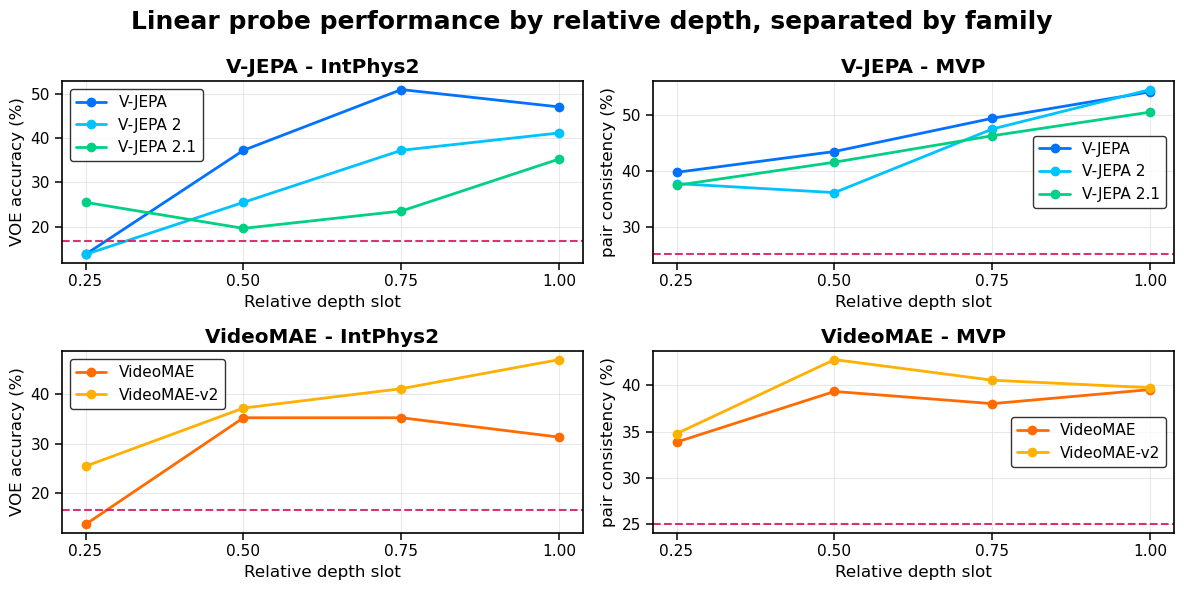

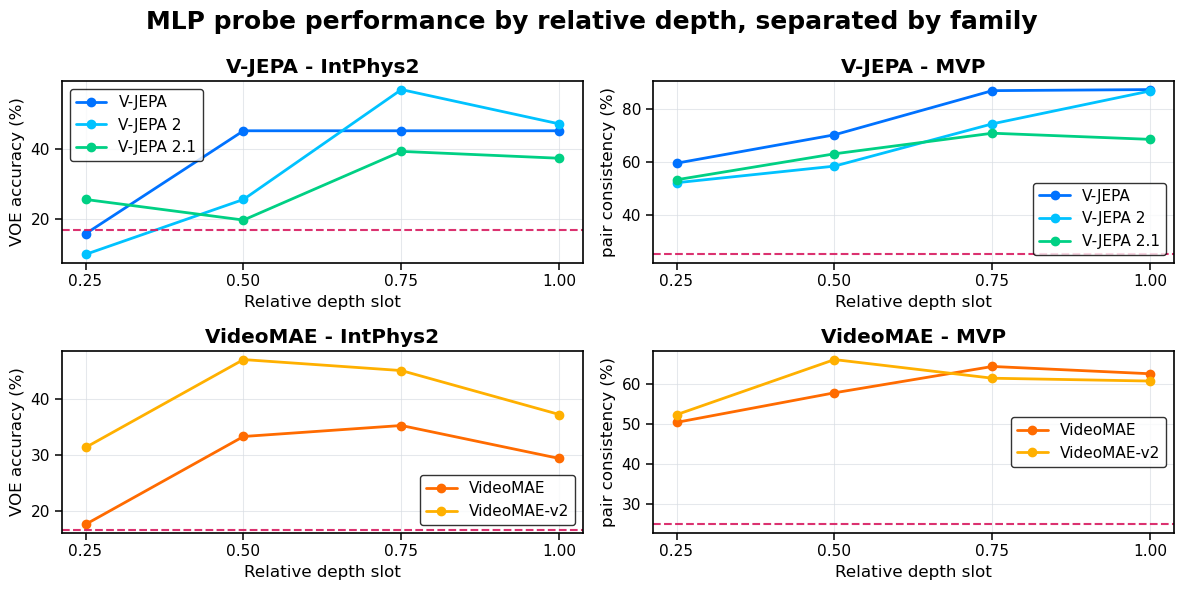

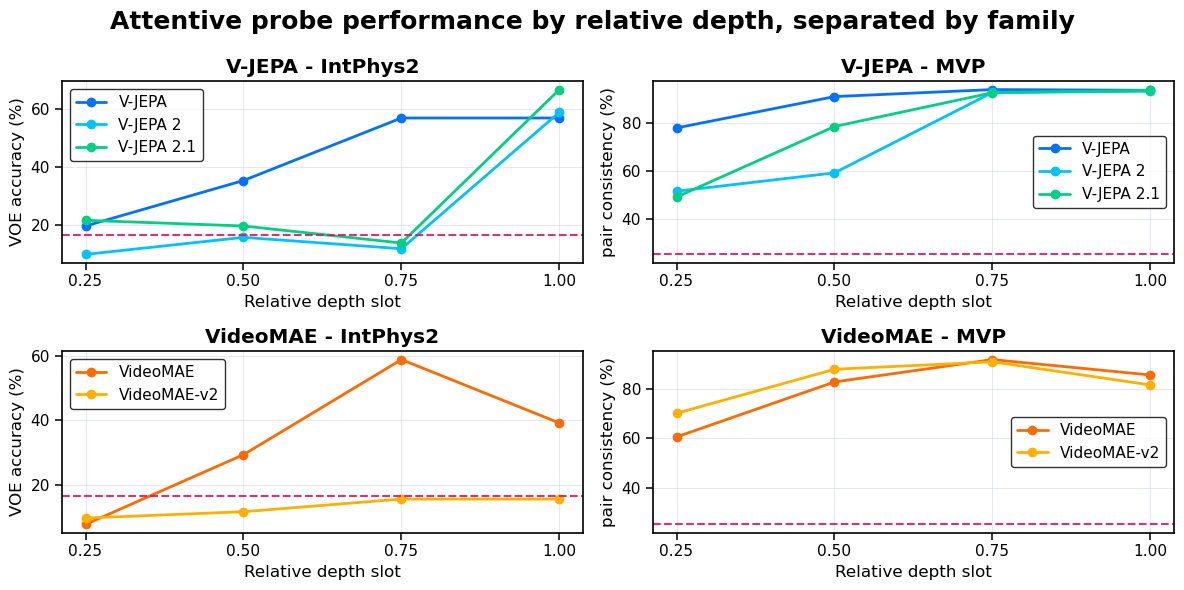

In [2]:
# Plot 2B
PLOT_2B_PROBES = ['linear', 'mlp', 'temporal_attn']
FIG_TITLES = {
    'linear': 'Linear probe performance by relative depth, separated by family',
    'mlp': 'MLP probe performance by relative depth, separated by family',
    'temporal_attn': 'Attentive probe performance by relative depth, separated by family',
}

for probe in PLOT_2B_PROBES:
    fig = plot_depth_by_family(probe_results, probe)
    fig.suptitle(FIG_TITLES[probe], fontsize=18)
    style_figure_text(fig)
    fig.tight_layout()
    plt.show()


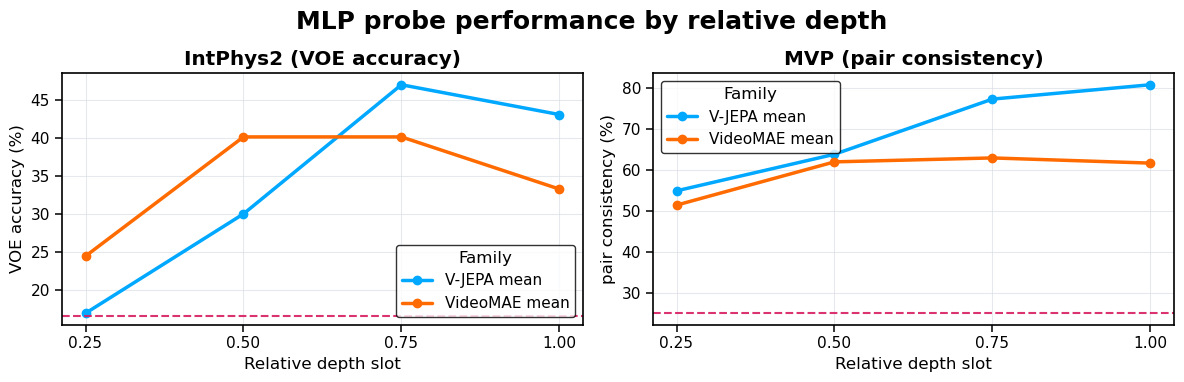

In [3]:
# Plot 2C, integrated into one figure
FIG_TITLE = 'MLP probe performance by relative depth'
fig = plot_depth_family_mean_integrated(probe_results, HEADLINE_PROBE)
fig.suptitle(FIG_TITLE, fontsize=18, y=0.95)
style_figure_text(fig)
fig.tight_layout()
plt.show()


/scratch-local/62771/ipykernel_2871253/3042295262.py:136: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, color=PLOT_GRID_COLOR, alpha=0.65, linewidth=0.75)
/scratch-local/62771/ipykernel_2871253/3042295262.py:136: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, color=PLOT_GRID_COLOR, alpha=0.65, linewidth=0.75)


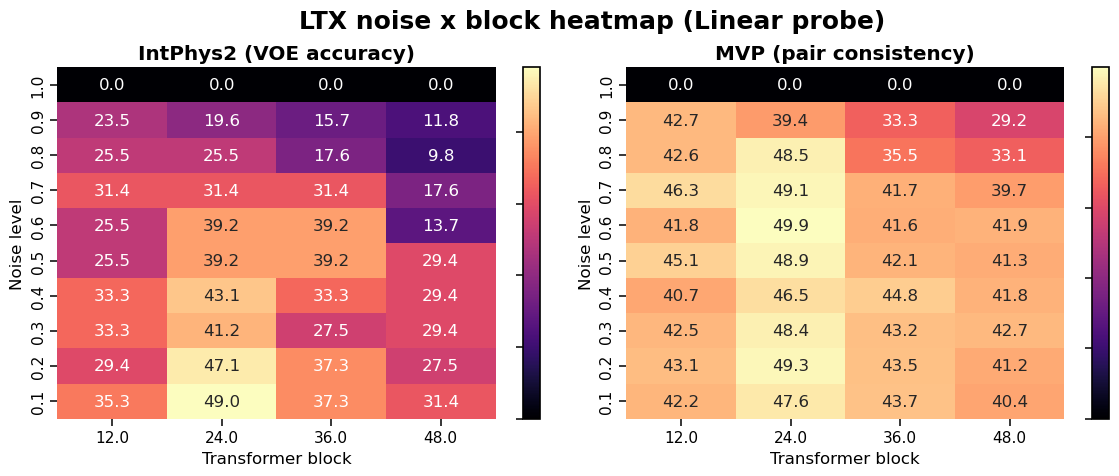

/scratch-local/62771/ipykernel_2871253/3042295262.py:136: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, color=PLOT_GRID_COLOR, alpha=0.65, linewidth=0.75)
/scratch-local/62771/ipykernel_2871253/3042295262.py:136: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, color=PLOT_GRID_COLOR, alpha=0.65, linewidth=0.75)


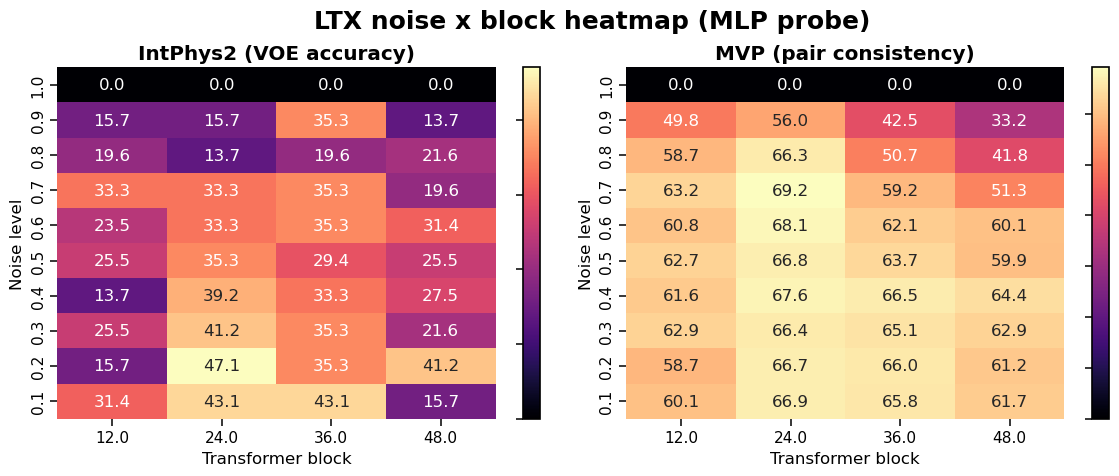

/scratch-local/62771/ipykernel_2871253/3042295262.py:136: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, color=PLOT_GRID_COLOR, alpha=0.65, linewidth=0.75)
/scratch-local/62771/ipykernel_2871253/3042295262.py:136: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, color=PLOT_GRID_COLOR, alpha=0.65, linewidth=0.75)


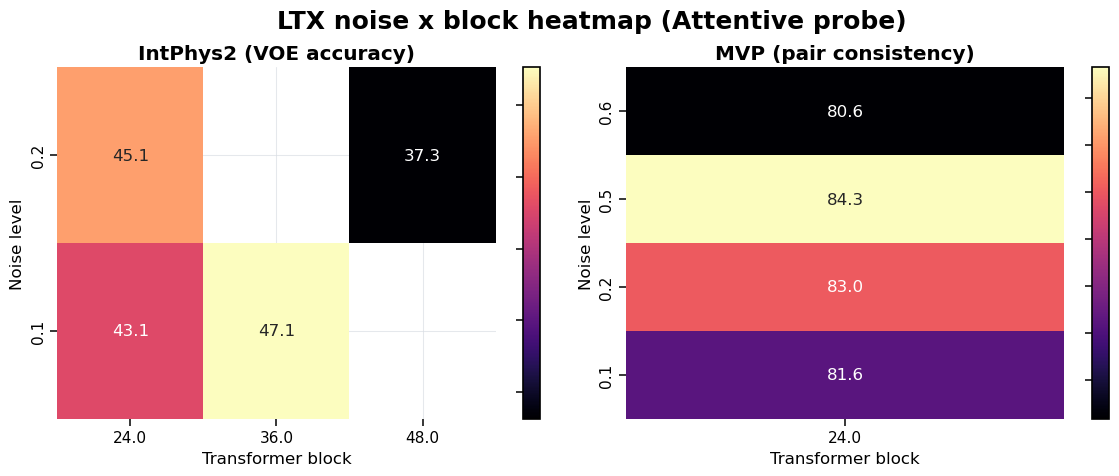

In [4]:
# Plot 2E
PLOT_2E_PROBES = ['linear', 'mlp', 'temporal_attn']
FIG_TITLES_2E = {
    'linear': 'LTX noise x block heatmap (Linear probe)',
    'mlp': 'LTX noise x block heatmap (MLP probe)',
    'temporal_attn': 'LTX noise x block heatmap (Attentive probe)'
}

for probe in PLOT_2E_PROBES:
    fig = plot_ltx_heatmap(probe_results, probe)
    fig.suptitle(FIG_TITLES_2E[probe], fontsize=18, y=0.95)
    style_figure_text(fig)
    fig.tight_layout()
    plt.show()


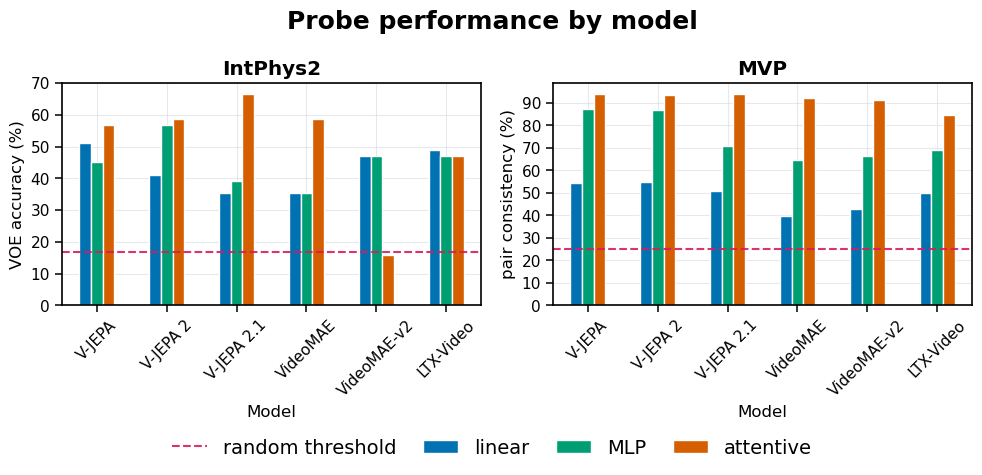

In [5]:
# Plot 3B
# MODEL_ORDER explicitly includes VideoMAE and VideoMAE-v2, so newly loaded rows appear in the grouped bars.
FIG_TITLE = 'Probe performance by model'
fig = plot_probe_performance_bars(best_layers)
fig.suptitle(FIG_TITLE, fontsize=18, y=0.93)
style_figure_text(fig)
fig.tight_layout(rect=[0, 0.075, 1, 0.95])
# fig.subplots_adjust(
#     wspace=0.5,
# )
plt.show()


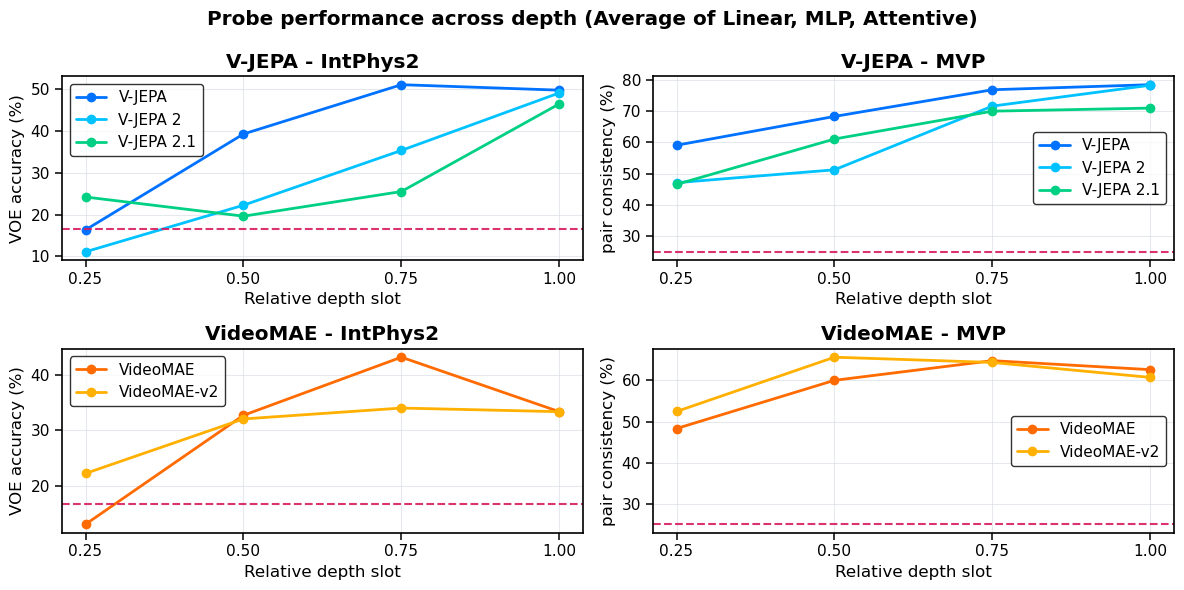

In [6]:
# Plot: Average probe performance by model vs layer depth
FIG_TITLE = 'Probe performance across depth (Average of Linear, MLP, Attentive)'
fig = plot_depth_average_probes_by_family(probe_results)
fig.suptitle(FIG_TITLE)
style_figure_text(fig)
fig.tight_layout()
plt.show()



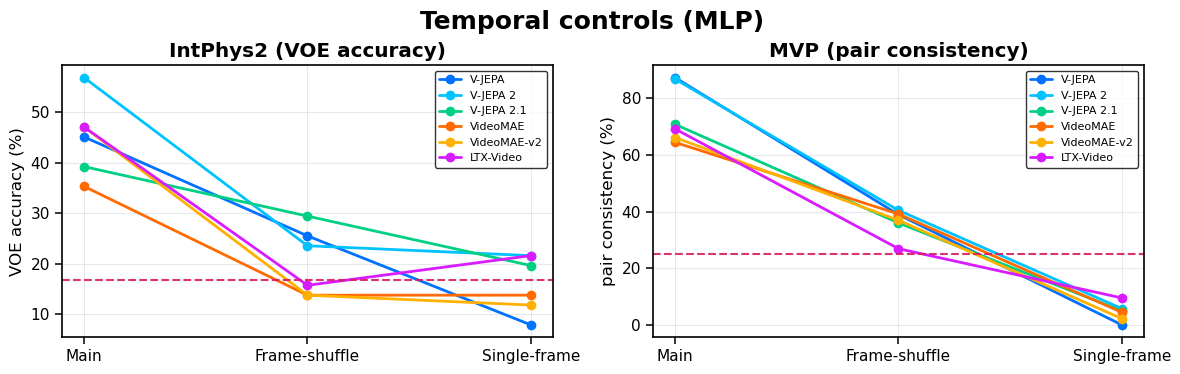

In [7]:
# Plot 4A
FIG_TITLE = 'Temporal controls (MLP)'
if control_comparison.empty:
    raise RuntimeError('No matching temporal-control rows were found for the selected main-task best layers.')
fig = plot_controls_connected(control_comparison)
fig.suptitle(FIG_TITLE, fontsize=18, y=0.93)
style_figure_text(fig)
fig.tight_layout()
plt.show()


In [8]:
print("Main Task Probe Results Paths:")
for p in sorted(selected_sources['source_path'].unique()):
    print(REPO_ROOT / p)

print("\nTemporal Control Results Paths:")
for p in sorted(controls['result_path'].unique()):
    print(REPO_ROOT / p)

Main Task Probe Results Paths:
/gpfs/home3/scur0511/Probe4Physics/artifacts/derived_probe_roots/mvp_probe_linear_ltx_video_complete_40_20260516/train_eval_summary.csv
/gpfs/home3/scur0511/Probe4Physics/artifacts/probes/intphys2/intphys2_ltx_linear_all_40_optuna/train_eval_summary.csv
/gpfs/home3/scur0511/Probe4Physics/artifacts/probes/intphys2/intphys2_probe_linear_jepa_v1_vith16_384_20260426T152120Z/train_eval_summary.csv
/gpfs/home3/scur0511/Probe4Physics/artifacts/probes/intphys2/intphys2_probe_linear_jepa_v2_1_vitG_384_20260430T105417Z/train_eval_summary.csv
/gpfs/home3/scur0511/Probe4Physics/artifacts/probes/intphys2/intphys2_probe_linear_videomae_v2_vit_giant_16_224_20260426T152148Z/intphys2_probe_linear_jepa_v2_vitg_384_20260430T105417Z/train_eval_summary.csv
/gpfs/home3/scur0511/Probe4Physics/artifacts/probes/intphys2/intphys2_probe_linear_videomae_v2_vit_giant_16_224_20260426T152148Z/train_eval_summary.csv
/gpfs/home3/scur0511/Probe4Physics/artifacts/probes/intphys2/intphys2_p